In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:

df = pd.read_csv("https://data.cityofnewyork.us/resource/aq7i-eu5q.csv")


In [8]:
df.head()

,sensor_name,sensor_id,flood_start_time,flood_end_time,max_depth_inches,onset_time_mins,drain_time_mins,duration_mins,duration_above_4_inches_mins,duration_above_12_inches_mins,duration_above_24_inches_mins,flood_profile_depth_inches,flood_profile_time_secs
0,Q - Beach 84 St,Q-beach-84-st-0me680,2023-10-30T12:00:39.000,2023-10-30T16:38:19.000,17.72,133.86,143.81,277.66,211.41,103.6,0.0,"[0.00, 0.87, 1.02, 1.38, 1.93, 2.64, 2.80, 3.1...","[0, 1008, 1134, 1512, 1826, 2079, 2142, 2206, ..."
1,BX - 1st St/Avenue A,BX-1st-st-avenue-a-1zby90,2025-04-26T23:17:20.000,2025-04-27T11:55:34.000,6.18,27.95,730.29,758.24,132.81,0.0,0.0,"[0.00, 0.71, 1.38, 1.38, 1.38, 1.38, 3.35, 4.6...","[0, 64, 129, 132, 196, 260, 324, 389, 453, 517..."
2,Q - Beach 35 St/Beach Channel Dr,Q-beach-35-st-beach-channel-dr-1oeug0,2024-02-09T11:41:01.000,2024-02-09T13:20:57.000,5.31,54.51,45.43,99.94,45.09,0.0,0.0,"[0.00, 0.43, 0.63, 0.71, 0.94, 1.18, 1.26, 1.5...","[0, 68, 136, 204, 273, 341, 409, 477, 545, 613..."
3,BX - Tibbett Ave/W 234th St,BX-w-234th-st-tibbett-ave-2cakho,2025-08-20T21:05:19.000,2025-08-21T00:46:19.000,1.18,80.00,141.00,221.00,0.00,0.0,0.0,"[0.00, 0.43, 0.47, 0.47, 0.51, 0.51, 0.51, 0.5...","[0, 60, 120, 180, 240, 300, 360, 420, 480, 540..."
4,Q - Davenport Ct 1,Q-davenport-ct-1-07zks0,2024-01-10T00:39:25.000,2024-01-10T02:30:40.000,2.09,59.82,51.43,111.25,0.00,0.0,0.0,"[0.00, 0.47, 0.47, 0.43, 0.43, 0.00, 0.00, 0.0...","[0, 63, 127, 189, 252, 315, 379, 505, 568, 631..."


In [11]:
df.columns

Index(['sensor_name', 'sensor_id', 'flood_start_time', 'flood_end_time',
       'max_depth_inches', 'onset_time_mins', 'drain_time_mins',
       'duration_mins', 'duration_above_4_inches_mins',
       'duration_above_12_inches_mins', 'duration_above_24_inches_mins',
       'flood_profile_depth_inches', 'flood_profile_time_secs'],
      dtype='object')

In [15]:

df["flood_start_time"] = pd.to_datetime(df["flood_start_time"])

In [16]:

df["year"] = df["flood_start_time"].dt.year

In [17]:

yearly_counts = df.groupby("year").size().reset_index(name="event_count")

In [18]:
print(yearly_counts)

   year  event_count
0  2020            1
1  2021           33
2  2022           65
3  2023          181
4  2024          308
5  2025          334
6  2026           78


In [31]:
df["max_depth_inches"].max()

46.14

In [32]:
top5_count = df["sensor_name"].value_counts().head(5)

print(top5_count)

sensor_name
Q - Beach 84 St                    180
BX - Ditmars St/Hunter Ave 2       136
Q - Russell St 1                    60
Q - 102nd St/160th Ave              42
Q - Brookville Blvd/ Snake Rd 1     40
Name: count, dtype: int64


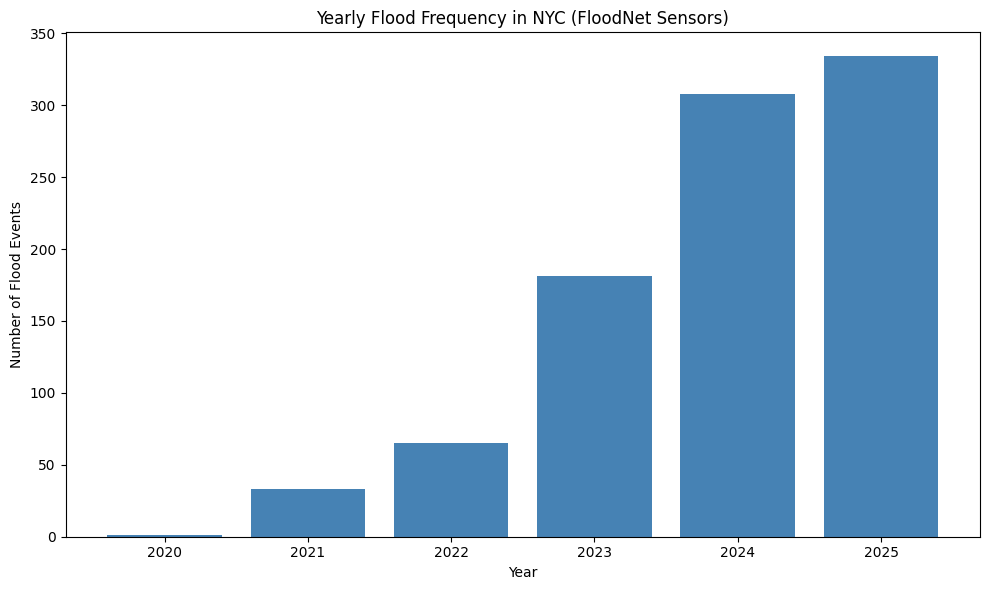

In [29]:
plt.figure(figsize=(10, 6))
plt.bar(yearly_counts["year"], yearly_counts["event_count"], color="steelblue")

plt.xlabel("Year")
plt.ylabel("Number of Flood Events")
plt.title("Yearly Flood Frequency in NYC (FloodNet Sensors)")
plt.xticks(yearly_counts["year"])
plt.tight_layout()
plt.show()

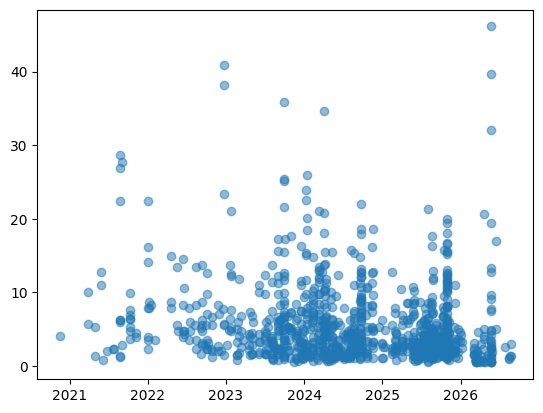

In [30]:
plt.scatter(df["flood_start_time"], df["max_depth_inches"], alpha=0.5)